<a target="_blank" href="https://colab.research.google.com/github/zhimingkuang/Harvard-AM-115/blob/main/08_monte_carlo/world_series.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 3-game "World Series"

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math

In [7]:
# generate a 3-game "world series". p is the probability that the better team wins the game; the series is over after a team has won two games
# returns number of games the losing team won
def world_series(p):
    # simulate the 3 games
    games = np.random.rand(3) < p

    if games[0] and games[1]:  # team 1 (stronger team) wins first two games, series is over - no need for game 3
        return 0
    elif not games[0] and not games[1]:  # team 2 (weaker team) wins first two games, series is over - no need for game 3
        return 0
    else:  # series goes to 3rd game - losing team won one game
        return 1

# simulate n_series world series with p
def simulate_world_series(p, n_series=44):
    results = np.zeros(n_series)
    for i in range(n_series):
        results[i] = world_series(p)
    return results

# run n_series world series N times
def run_simulations(p, N=10000, n_series=44):
    all_results = np.zeros(N)
    for i in range(N):
        # number of 0s in n_series world series
        all_results[i] = np.sum(simulate_world_series(p, n_series=n_series) == 0)
    return all_results

# get PDF of number of games won by losing team across n_series world series for p
def get_pdf(p, N=10000, n_series=44):
    all_results = run_simulations(p, N=N, n_series=n_series)
    pdf = np.zeros(n_series + 1)
    for i in range(n_series + 1):
        pdf[i] = np.mean(all_results == i)
    return pdf

# generate likelihood for p given n_series world series with x 0s (x games won by losing team)
def likelihood(p, x, n_series=44, N =10000):
    pdf = get_pdf(p, N=N, n_series=n_series)
    return pdf[x]

def likelihood_analytical(p, x, n_series=44):
    # probability of losing team winning 0 games is p^2 + (1-p)^2
    # probability of losing team winning 1 game is 2*p*(1-p)
    p1 = p**2 + (1-p)**2
    p2 = 2*p*(1-p)
    return math.comb(n_series, x) * (p1**x) * (p2**(n_series - x))

### Probability mass function of the losing team winning 0 number of games x times in the 44 series

In [ ]:
def plot_world_series_histogram(p, N=10000, n_series=44):
    """Plot histogram of number of sweeps (0 games won by loser) in n_series world series."""
    all_results = run_simulations(p, N=N, n_series=n_series)
    bins = np.arange(1, n_series + 1, 1)
    plt.hist(all_results, bins=bins, density=True)

    mode_value = stats.mode(all_results, keepdims=False).mode
    plt.axvline(mode_value, color='red', linestyle='--', linewidth=2, label=f'Mode = {mode_value:.1f}')
    plt.legend()

    plt.title(f'Number of 0 games won by losing team in {n_series} world series\nN={N}, p={p}')
    plt.ylabel('Probability')
    plt.xlabel(f'x (number of 0 games won by losing team in {n_series} world series)')
    plt.show()

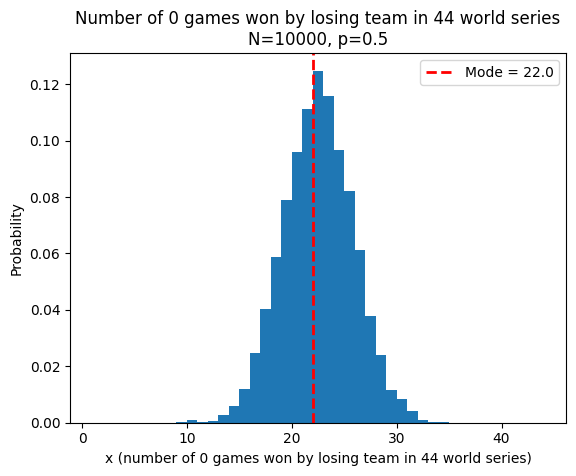

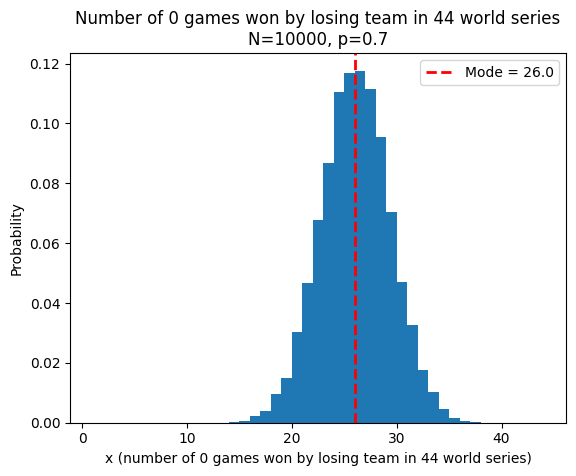

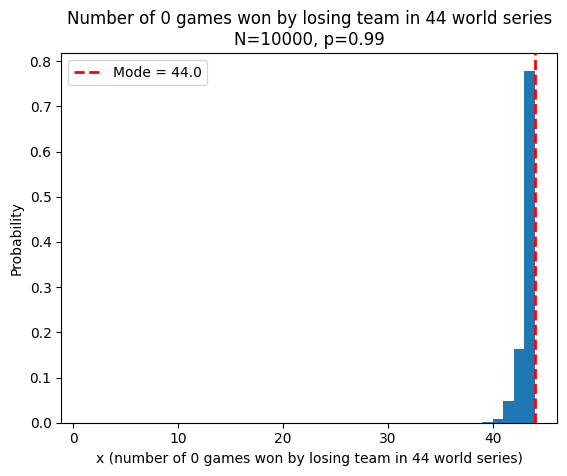

In [ ]:
plot_world_series_histogram(p=0.5, N=10000)
plot_world_series_histogram(p=0.7, N=10000)
plot_world_series_histogram(p=0.99, N=10000)

## Likelihood (given p, the probability of x number of 0 games won by losing team in 44 world series)
For 44 “world series” with the losing team won 0 game 31 times and 1 game 13 times; we can estimate p based on maximum likelihood estimation

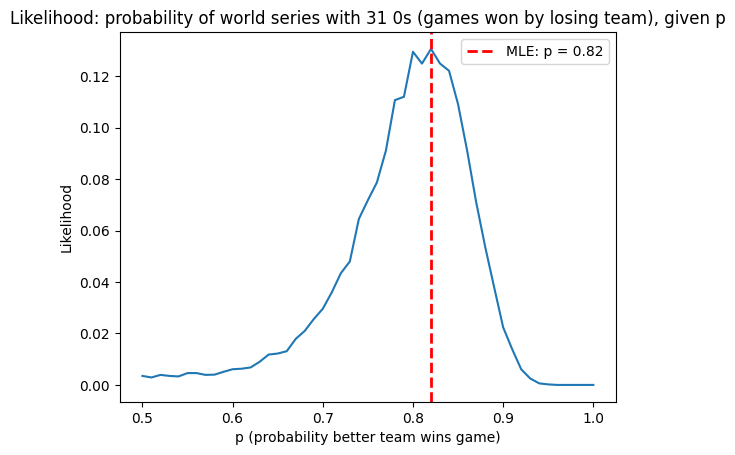

CPU times: user 1min 20s, sys: 68.9 ms, total: 1min 20s
Wall time: 1min 22s


In [ ]:
%%time

# loop through different values of p (from 0.5 to 1) and plot likelihood of p given n_series world series with x 0s (x games won by losing team)
def plot_likelihood(x, n_series=44, N=10000):
    ps = np.linspace(0.5, 1, 51)
    likelihoods = np.zeros(len(ps))
    for i, p in enumerate(ps):
        likelihoods[i] = likelihood(p, x, n_series=n_series, N=N)

    plt.plot(ps, likelihoods)

    # plot likelihood_analytical
    likelihoods_analytical = np.zeros(len(ps))
    for i, p in enumerate(ps):
        likelihoods_analytical[i] = likelihood_analytical(p, x, n_series=n_series)
    plt.plot(ps, likelihoods_analytical, label='Analytical Likelihood', linestyle='--')

    # Draw line where likelihood is maximized
    max_idx = np.argmax(likelihoods)
    p_mle = ps[max_idx]
    plt.axvline(p_mle, color='red', linestyle='--', linewidth=2, label=f'MLE from MC: p = {p_mle:.2f}')
    plt.legend()

    plt.title(f'Likelihood: probability of world series with {x} 0s (games won by losing team), given p')
    plt.xlabel('p (probability better team wins game)')
    plt.ylabel('Likelihood')
    plt.show()


# Example usage:
plot_likelihood(x=31, n_series=44, N=10000)